# Training Notebook
## Checklist
- [x] Clone and inspect the BSDS500 repo locally
- [x] Write a script to load one image and one .mat annotation
- [x] Decide label construction rule: averaged soft edge map or thresholded consensus
- [x] Implement the PyTorch dataset/dataloader
 - [x]   Fix the image size to 162x121 and grayscale
 - [x]   Implement the tiny FCN
 - [x]   Train with weighted BCE
 - [x]   Save validation prediction panels every few epochs
 - [x]   Pick the best checkpoint
 - [x]   Export a golden set of 5-10 samples
 - [x]   Document the inference contract for HLS


In [1]:
from pathlib import Path
from collections import Counter
import numpy as np
from PIL import Image
from scipy.io import loadmat

# Point to the BSDS500 dataset root (adjust if your workspace layout changes)
bsds_root = Path("../BSDS500-master/BSDS500/data").resolve()
images_root = bsds_root / "images"
gt_root = bsds_root / "groundTruth"
splits = ["train", "val", "test"]

print(f"BSDS root: {bsds_root}")
print(f"Images root exists: {images_root.exists()}")
print(f"GroundTruth root exists: {gt_root.exists()}")

# 1) List image file names
image_paths = []
for split in splits:
    split_dir = images_root / split
    split_imgs = sorted(split_dir.glob("*.jpg")) if split_dir.exists() else []
    image_paths.extend(split_imgs)
    print(f"{split:>5}: {len(split_imgs)} images")

print(f"\nTotal images found: {len(image_paths)}")
print("First 20 image file names:")
for p in image_paths[:20]:
    print(" -", p.name)

# 2) Match image files to .mat files
image_stems = {p.stem for p in image_paths}
mat_paths = []
for split in splits:
    split_dir = gt_root / split
    split_mats = sorted(split_dir.glob("*.mat")) if split_dir.exists() else []
    mat_paths.extend(split_mats)
    print(f"{split:>5}: {len(split_mats)} .mat annotations")

mat_stems = {p.stem for p in mat_paths}
matched = sorted(image_stems & mat_stems)
missing_mat = sorted(image_stems - mat_stems)
orphan_mat = sorted(mat_stems - image_stems)

print(f"\nMatched image/.mat pairs: {len(matched)}")
print(f"Images without .mat: {len(missing_mat)}")
print(f".mat files without image: {len(orphan_mat)}")

if missing_mat:
    print("Missing .mat examples:", missing_mat[:10])
if orphan_mat:
    print("Orphan .mat examples:", orphan_mat[:10])

# 3) Print image size distribution
sizes = []
for img_path in image_paths:
    with Image.open(img_path) as im:
        sizes.append((im.width, im.height))

size_counts = Counter(sizes)
print(f"\nUnique image sizes: {len(size_counts)}")
print("Top 10 size frequencies (width, height -> count):")
for (w, h), count in size_counts.most_common(10):
    print(f"  ({w:4d}, {h:4d}) -> {count}")

widths = np.array([w for w, _ in sizes], dtype=np.int32)
heights = np.array([h for _, h in sizes], dtype=np.int32)
print("\nWidth stats: ", {"min": int(widths.min()), "max": int(widths.max()), "mean": float(widths.mean())})
print("Height stats:", {"min": int(heights.min()), "max": int(heights.max()), "mean": float(heights.mean())})

# 4) Load one .mat file and inspect annotation fields
if mat_paths:
    sample_mat = mat_paths[0]
    print(f"\nInspecting sample .mat: {sample_mat}")
    data = loadmat(sample_mat)

    top_keys = [k for k in data.keys() if not k.startswith("__")]
    print("Top-level keys:", top_keys)

    if "groundTruth" in data:
        gt = data["groundTruth"]
        print("groundTruth type:", type(gt), "shape:", gt.shape, "dtype:", gt.dtype)

        # BSDS stores annotations as a MATLAB cell array of structs.
        # This prints fields in the first annotator entry.
        first_entry = gt[0, 0]
        print("First entry type:", type(first_entry), "dtype:", first_entry.dtype)
        print("First entry fields:", first_entry.dtype.names)

        if first_entry.dtype.names:
            for field in first_entry.dtype.names:
                field_value = first_entry[field][0, 0]
                arr = np.asarray(field_value)
                print(f" - field '{field}': shape={arr.shape}, dtype={arr.dtype}")
else:
    print("\nNo .mat files found to inspect.")

BSDS root: C:\Users\brand\Documents\engs192\zybo-edge-ai\BSDS500-master\BSDS500\data
Images root exists: True
GroundTruth root exists: True
train: 200 images
  val: 100 images
 test: 200 images

Total images found: 500
First 20 image file names:
 - 100075.jpg
 - 100080.jpg
 - 100098.jpg
 - 103041.jpg
 - 104022.jpg
 - 105019.jpg
 - 105053.jpg
 - 106020.jpg
 - 106025.jpg
 - 108041.jpg
 - 108073.jpg
 - 109034.jpg
 - 112082.jpg
 - 113009.jpg
 - 113016.jpg
 - 113044.jpg
 - 117054.jpg
 - 118020.jpg
 - 118035.jpg
 - 12003.jpg
train: 200 .mat annotations
  val: 100 .mat annotations
 test: 200 .mat annotations

Matched image/.mat pairs: 500
Images without .mat: 0
.mat files without image: 0

Unique image sizes: 2
Top 10 size frequencies (width, height -> count):
  ( 481,  321) -> 348
  ( 321,  481) -> 152

Width stats:  {'min': 321, 'max': 481, 'mean': 432.36}
Height stats: {'min': 321, 'max': 481, 'mean': 369.64}

Inspecting sample .mat: C:\Users\brand\Documents\engs192\zybo-edge-ai\BSDS500-ma

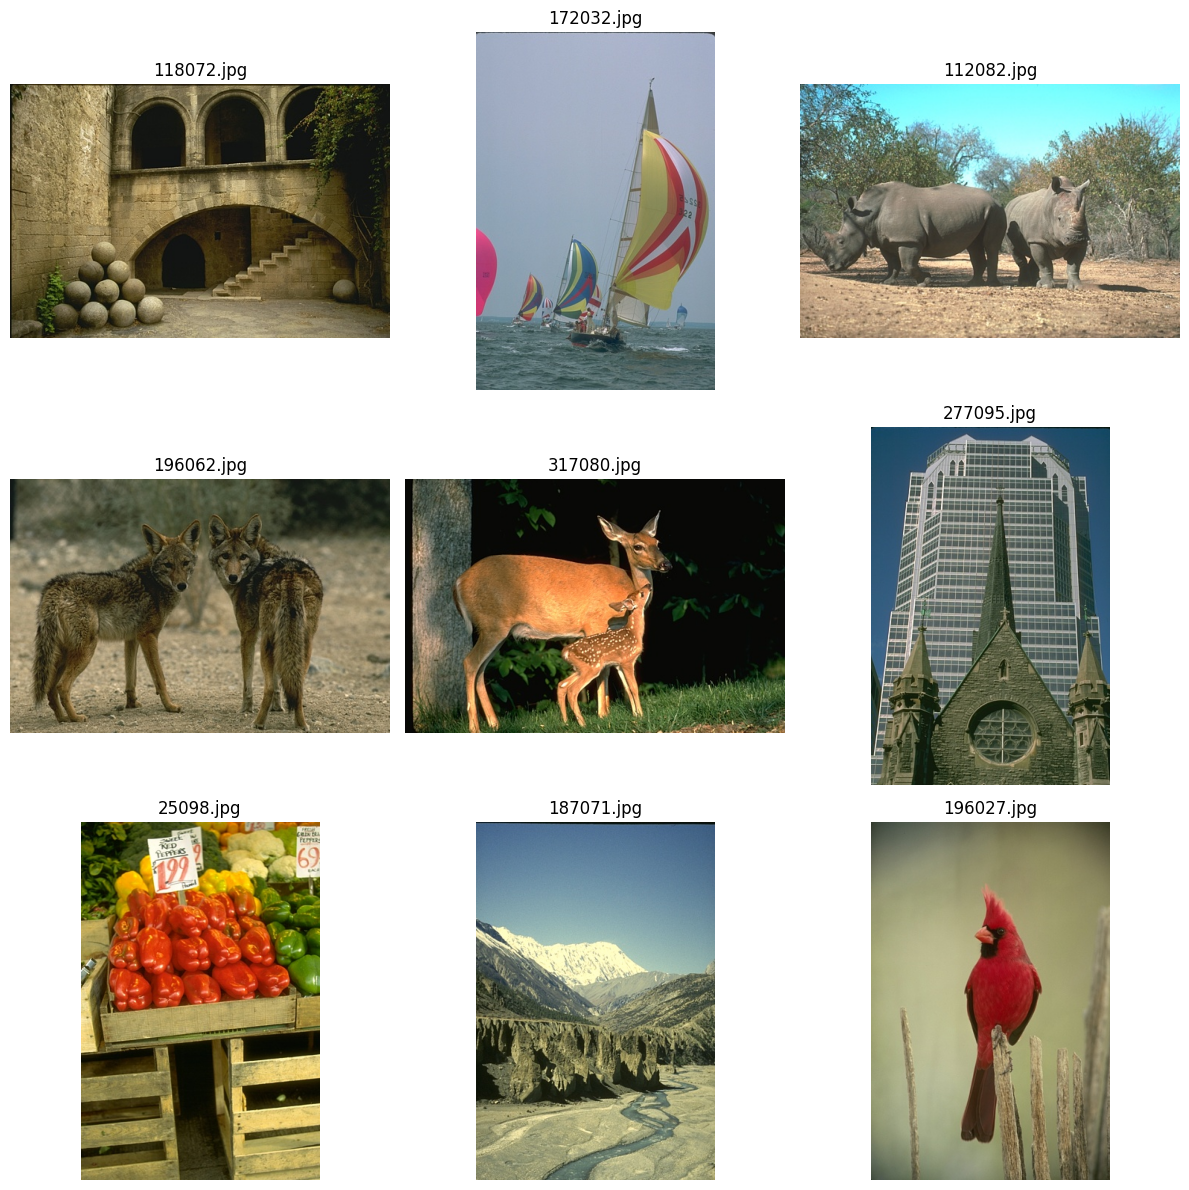

In [2]:
import random
import matplotlib.pyplot as plt
from PIL import Image

# Display a small grid of sample BSDS500 images
# Reuse image_paths from the previous cell if available; otherwise rebuild quickly.
try:
    image_paths
except NameError:
    from pathlib import Path
    bsds_root = Path("../BSDS500-master/BSDS500/data").resolve()
    images_root = bsds_root / "images"
    splits = ["train", "val", "test"]
    image_paths = []
    for split in splits:
        image_paths.extend(sorted((images_root / split).glob("*.jpg")))

n_show = min(9, len(image_paths))
random.seed(42)
samples = random.sample(image_paths, n_show) if n_show > 0 else []

if not samples:
    print("No images found to display.")
else:
    cols = 3
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))

    # Make axes iterable for both 1-row and multi-row layouts
    if rows == 1:
        axes = [axes] if cols == 1 else axes

    flat_axes = list(axes.ravel()) if hasattr(axes, "ravel") else list(axes)

    for ax, img_path in zip(flat_axes, samples):
        with Image.open(img_path) as im:
            ax.imshow(im)
        ax.set_title(img_path.name)
        ax.axis("off")

    # Hide any unused subplot panels
    for ax in flat_axes[len(samples):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## Theory: What This Model Is Learning
This project treats edge detection as **dense binary classification**. For every pixel, the CNN predicts a value between 0 and 1 that answers: "how likely is this pixel to belong to a perceptual boundary?"
A few important ideas drive the design:
- **Why BSDS500 is useful:** each image has several human annotators, so edges are not perfectly objective. That means labels are naturally uncertain.
- **Soft labels vs hard labels:** if 5 out of 6 annotators marked a boundary at a pixel, the target can be 5/6 instead of forcing a hard 1. This usually trains more smoothly than a hard threshold because it keeps uncertainty instead of discarding it.
- **Why weighted BCE:** edge pixels are sparse. Most pixels are background, so an unweighted loss would let the model get a low loss by predicting near-zero everywhere. pos_weight increases the penalty for missing true edges.
- **Why a fully convolutional network:** we need one output per pixel, so the network should preserve spatial layout rather than collapse everything into a single class prediction.
- **Why grayscale and fixed size:** grayscale reduces compute and simplifies the first hardware version. Fixing the size to 162x121 gives the FPGA/HLS side a stable inference contract.


In [ ]:
import math
import time
from dataclasses import dataclass
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
TARGET_WIDTH = 162
TARGET_HEIGHT = 121
TARGET_SIZE = (TARGET_WIDTH, TARGET_HEIGHT)
LABEL_MODE = "soft"  # choose from: 'soft' or 'consensus'
CONSENSUS_THRESHOLD = 0.5
BATCH_SIZE = 8
EPOCHS = 15
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
PANEL_EVERY = 3
NUM_WORKERS = 2
artifacts_root = Path("./artifacts")
checkpoints_dir = artifacts_root / "checkpoints"
panels_dir = artifacts_root / "val_panels"
golden_dir = artifacts_root / "golden_set"
for path in [artifacts_root, checkpoints_dir, panels_dir, golden_dir]:
    path.mkdir(parents=True, exist_ok=True)


In [ ]:
def load_boundary_stack(mat_path: Path) -> np.ndarray:
    """Return annotator boundary maps stacked as [N, H, W]."""
    data = loadmat(mat_path)
    gt = data["groundTruth"]
    boundaries = []
    for idx in range(gt.shape[1]):
        entry = gt[0, idx]
        boundary = np.asarray(entry["Boundaries"][0, 0], dtype=np.float32)
        boundaries.append(boundary)
    return np.stack(boundaries, axis=0)
def build_edge_target(boundary_stack: np.ndarray, mode: str = "soft", consensus_threshold: float = 0.5) -> np.ndarray:
    """Collapse multiple annotators into one training target."""
    avg = boundary_stack.mean(axis=0, dtype=np.float32)
    if mode == "soft":
        return avg
    if mode == "consensus":
        return (avg >= consensus_threshold).astype(np.float32)
    raise ValueError(f"Unsupported label mode: {mode}")
sample_image_path = image_paths[0]
sample_mat_path = gt_root / "train" / f"{sample_image_path.stem}.mat"
with Image.open(sample_image_path) as im:
    sample_rgb = np.asarray(im)
sample_stack = load_boundary_stack(sample_mat_path)
sample_soft = build_edge_target(sample_stack, mode="soft")
sample_consensus = build_edge_target(sample_stack, mode="consensus", consensus_threshold=CONSENSUS_THRESHOLD)
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(sample_rgb)
axes[0].set_title("RGB image")
axes[1].imshow(sample_stack.mean(axis=0), cmap="magma")
axes[1].set_title("Mean annotator edge map")
axes[2].imshow(sample_soft, cmap="gray", vmin=0.0, vmax=1.0)
axes[2].set_title("Soft label")
axes[3].imshow(sample_consensus, cmap="gray", vmin=0.0, vmax=1.0)
axes[3].set_title("Consensus label")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()
print("Boundary stack shape:", sample_stack.shape)
print("Soft label range:", float(sample_soft.min()), float(sample_soft.max()))
print("Consensus positive fraction:", float(sample_consensus.mean()))


## Label Decision
Use the **averaged soft edge map** for training unless you have a strong hardware reason to force binary supervision.
Why this is the better first choice here:
- It respects annotator disagreement instead of throwing it away.
- It makes the target less brittle after resizing, because thin edges can partially occupy a pixel.
- BCEWithLogitsLoss works with targets in [0, 1], so soft supervision is a natural fit.
A consensus map is still useful later if you want a stricter metric or a post-training thresholding rule.


In [ ]:
@dataclass
class SampleRecord:
    split: str
    image_path: Path
    mat_path: Path
def build_split_records(split: str):
    img_dir = images_root / split
    mat_dir = gt_root / split
    records = []
    for image_path in sorted(img_dir.glob("*.jpg")):
        mat_path = mat_dir / f"{image_path.stem}.mat"
        if mat_path.exists():
            records.append(SampleRecord(split=split, image_path=image_path, mat_path=mat_path))
    return records
def resize_image_gray(image: Image.Image) -> torch.Tensor:
    image = image.convert("L")
    image = TF.resize(image, [TARGET_HEIGHT, TARGET_WIDTH], interpolation=InterpolationMode.BILINEAR)
    tensor = TF.to_tensor(image)
    return tensor
def resize_target(target: np.ndarray) -> torch.Tensor:
    target_tensor = torch.from_numpy(target).float().unsqueeze(0).unsqueeze(0)
    target_tensor = F.interpolate(
        target_tensor,
        size=(TARGET_HEIGHT, TARGET_WIDTH),
        mode="bilinear",
        align_corners=False,
    )
    return target_tensor.squeeze(0)
class BSDS500EdgeDataset(Dataset):
    def __init__(self, split: str, label_mode: str = "soft", consensus_threshold: float = 0.5):
        self.records = build_split_records(split)
        self.label_mode = label_mode
        self.consensus_threshold = consensus_threshold
    def __len__(self):
        return len(self.records)
    def __getitem__(self, idx: int):
        record = self.records[idx]
        with Image.open(record.image_path) as image:
            image_tensor = resize_image_gray(image)
        boundary_stack = load_boundary_stack(record.mat_path)
        target = build_edge_target(boundary_stack, mode=self.label_mode, consensus_threshold=self.consensus_threshold)
        target_tensor = resize_target(target)
        return {
            "image": image_tensor,
            "target": target_tensor,
            "stem": record.image_path.stem,
            "split": record.split,
        }
train_ds = BSDS500EdgeDataset("train", label_mode=LABEL_MODE, consensus_threshold=CONSENSUS_THRESHOLD)
val_ds = BSDS500EdgeDataset("val", label_mode=LABEL_MODE, consensus_threshold=CONSENSUS_THRESHOLD)
test_ds = BSDS500EdgeDataset("test", label_mode=LABEL_MODE, consensus_threshold=CONSENSUS_THRESHOLD)
print("Dataset sizes:", {"train": len(train_ds), "val": len(val_ds), "test": len(test_ds)})
sample = train_ds[0]
print("Image tensor shape:", tuple(sample["image"].shape))
print("Target tensor shape:", tuple(sample["target"].shape))
print("Image range:", float(sample["image"].min()), float(sample["image"].max()))
print("Target range:", float(sample["target"].min()), float(sample["target"].max()))


In [ ]:
def make_loader(dataset, shuffle: bool):
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )
def estimate_pos_weight(dataset: Dataset, max_samples: int | None = None) -> float:
    positives = 0.0
    total = 0.0
    count = len(dataset) if max_samples is None else min(len(dataset), max_samples)
    for idx in range(count):
        target = dataset[idx]["target"]
        positives += float(target.sum().item())
        total += float(target.numel())
    negatives = max(total - positives, 1.0)
    positives = max(positives, 1.0)
    return negatives / positives
train_loader = make_loader(train_ds, shuffle=True)
val_loader = make_loader(val_ds, shuffle=False)
pos_weight_value = estimate_pos_weight(train_ds, max_samples=100)
print(f"Estimated pos_weight: {pos_weight_value:.3f}")


## Model Design
This is a **tiny fully convolutional network**. It never flattens the image into a single vector, so spatial layout is preserved from input to output.
The intuition for each stage:
- Early convolutions learn local edge primitives such as intensity jumps and small orientations.
- Middle convolutions combine those primitives into more stable contours.
- The final 1x1 convolution converts feature channels into one logit per pixel.
Because all convolutions use stride 1 and padding that preserves size, the output remains 121x162. That simplicity is useful both for debugging and for eventual HLS deployment.


In [ ]:
class TinyEdgeFCN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 1, kernel_size=1),
        )
    def forward(self, x):
        return self.net(x)
model = TinyEdgeFCN().to(device)
dummy = torch.zeros(1, 1, TARGET_HEIGHT, TARGET_WIDTH, device=device)
out = model(dummy)
print(model)
print("Output shape:", tuple(out.shape))
print("Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))


In [ ]:
def save_prediction_panel(model: nn.Module, dataset: Dataset, epoch: int, out_dir: Path, n_samples: int = 4):
    model.eval()
    n_samples = min(n_samples, len(dataset))
    indices = list(range(n_samples))
    fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))
    if n_samples == 1:
        axes = np.expand_dims(axes, axis=0)
    with torch.no_grad():
        for row, idx in enumerate(indices):
            sample = dataset[idx]
            image = sample["image"].unsqueeze(0).to(device)
            logits = model(image)
            pred = torch.sigmoid(logits).squeeze().cpu().numpy()
            image_np = sample["image"].squeeze().cpu().numpy()
            target_np = sample["target"].squeeze().cpu().numpy()
            axes[row, 0].imshow(image_np, cmap="gray")
            axes[row, 0].set_title(f"Input: {sample['stem']}")
            axes[row, 1].imshow(target_np, cmap="gray", vmin=0.0, vmax=1.0)
            axes[row, 1].set_title("Target")
            axes[row, 2].imshow(pred, cmap="gray", vmin=0.0, vmax=1.0)
            axes[row, 2].set_title("Prediction")
            for col in range(3):
                axes[row, col].axis("off")
    plt.tight_layout()
    out_path = out_dir / f"epoch_{epoch:03d}.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return out_path
def run_epoch(model: nn.Module, loader: DataLoader, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    total_items = 0
    for batch in loader:
        images = batch["image"].to(device)
        targets = batch["target"].to(device)
        logits = model(images)
        loss = criterion(logits, targets)
        if training:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
        batch_size = images.shape[0]
        total_loss += float(loss.item()) * batch_size
        total_items += batch_size
    return total_loss / max(total_items, 1)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_value], device=device))
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
history = []
best_val_loss = math.inf
best_checkpoint_path = checkpoints_dir / "best_tiny_edge_fcn.pt"
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_loss = run_epoch(model, train_loader, criterion, optimizer=optimizer)
    val_loss = run_epoch(model, val_loader, criterion, optimizer=None)
    elapsed = time.time() - t0
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
    print(f"Epoch {epoch:02d}/{EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | {elapsed:.1f}s")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            {
                "model_state": model.state_dict(),
                "config": {
                    "target_width": TARGET_WIDTH,
                    "target_height": TARGET_HEIGHT,
                    "label_mode": LABEL_MODE,
                    "consensus_threshold": CONSENSUS_THRESHOLD,
                    "pos_weight": pos_weight_value,
                },
                "history": history,
            },
            best_checkpoint_path,
        )
        print("  saved best checkpoint ->", best_checkpoint_path)
    if epoch == 1 or epoch % PANEL_EVERY == 0:
        panel_path = save_prediction_panel(model, val_ds, epoch, panels_dir, n_samples=4)
        print("  saved validation panel ->", panel_path)
print("Best validation loss:", best_val_loss)


In [ ]:
checkpoint = torch.load(best_checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state"])
model.eval()
epochs = [item["epoch"] for item in history]
train_losses = [item["train_loss"] for item in history]
val_losses = [item["val_loss"] for item in history]
plt.figure(figsize=(7, 4))
plt.plot(epochs, train_losses, marker="o", label="train")
plt.plot(epochs, val_losses, marker="o", label="val")
plt.xlabel("Epoch")
plt.ylabel("Weighted BCE loss")
plt.title("Training curve")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [ ]:
def export_golden_set(model: nn.Module, dataset: Dataset, out_dir: Path, n_samples: int = 8):
    model.eval()
    out_dir.mkdir(parents=True, exist_ok=True)
    manifest_lines = ["stem,input_npy,target_npy,pred_npy"]
    with torch.no_grad():
        for idx in range(min(n_samples, len(dataset))):
            sample = dataset[idx]
            stem = sample["stem"]
            image = sample["image"].unsqueeze(0).to(device)
            pred = torch.sigmoid(model(image)).squeeze().cpu().numpy().astype(np.float32)
            image_np = sample["image"].squeeze().cpu().numpy().astype(np.float32)
            target_np = sample["target"].squeeze().cpu().numpy().astype(np.float32)
            input_path = out_dir / f"{stem}_input.npy"
            target_path = out_dir / f"{stem}_target.npy"
            pred_path = out_dir / f"{stem}_pred.npy"
            np.save(input_path, image_np)
            np.save(target_path, target_np)
            np.save(pred_path, pred)
            manifest_lines.append(f"{stem},{input_path.name},{target_path.name},{pred_path.name}")
    manifest_path = out_dir / "manifest.csv"
    manifest_path.write_text("\n".join(manifest_lines) + "\n", encoding="utf-8")
    return manifest_path
manifest_path = export_golden_set(model, val_ds, golden_dir, n_samples=8)
print("Golden set manifest:", manifest_path)


## Inference Contract For HLS
Treat the trained CNN as a deterministic function with this contract:
- **Input shape:** 1 x 121 x 162 grayscale tensor.
- **Input dtype/range:** floating-point values normalized to [0, 1] from an 8-bit grayscale image.
- **Preprocessing:** convert RGB to grayscale, then resize to 162x121 using bilinear interpolation.
- **Output shape:** 1 x 121 x 162 logit map before sigmoid, or probability map after sigmoid.
- **Postprocessing for visualization:** apply sigmoid, then threshold later if you need a binary edge image.
- **Training label type:** soft edge targets in [0, 1], produced by averaging annotator boundary maps.
- **Reference artifacts:** use the exported golden-set .npy files to validate that software and HLS produce numerically similar outputs.
For FPGA deployment, the usual next step is to freeze this contract first, then decide whether to quantize weights/activations. Quantization is much easier once preprocessing, tensor order, and output interpretation are fixed.


## Colab Notes
When you move this notebook to Google Colab, the practical flow is:
1. Upload or mount the BSDS500 dataset so the sds_root path is correct.
2. Keep the notebook outputs under rtifacts/ or redirect them into Google Drive.
3. Train in Colab with GPU enabled, then download the best checkpoint and the golden set.
If you later want to target HLS more aggressively, the next design step is usually reducing channel counts further or introducing fixed-point-aware export.
